In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import logging, sys
import math

from radioimaging.deconvolution import deconvolve
from radioimaging.util import util

matplotlib.rcParams['figure.figsize'] = [6, 5]
cmap = "turbo"

In [2]:
num_partitions = 10
prev_estimates = []
mc = 3
partition = 0
init_lambda = 0.02
total_mc = 5
ells = [21.03, 39.66, 54.19, 65.89, 75.94, 92.49, 109.8, 132.0, 145.79]
delta = 1
variance_window = 5
deconv_partitions = [1] * 10
k = 10

first_res_var = numpy.mean(deconvolve.compute_windowed_var(util.fromfits("~/test/10/pl1/residual_" + str(partition) + "_0.fits"), variance_window))

for i in range(10):
    prev_estimates.append(util.fromfits("~/test/10/pl1/recon_" + str(i) + "_" + str(mc - 1) + ".fits"))

resid = util.fromfits("~/test/10/pl1/residual_" + str(partition) + "_" + str(mc) + ".fits")
psf = util.fromfits("~/test/10/pl1/psf_" + str(partition) + ".fits")

t = float(mc) / (float(total_mc) - 1)
curr_lambda = init_lambda + (1 - init_lambda) * ((numpy.exp(k * t) - 1) / (numpy.exp(k) - 1))

In [3]:
deconv = deconvolve.deconvolve_multipartition(partition, resid, psf, prev_estimates, 200, mc, curr_lambda, ells, delta, variance_window, first_res_var, deconv_partitions)

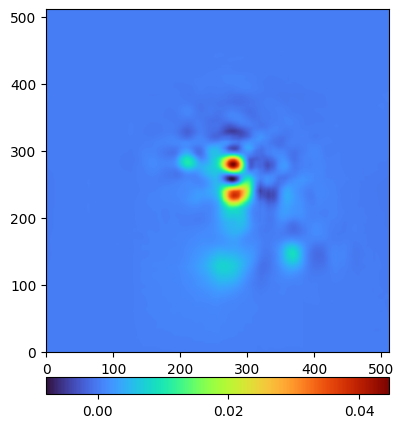

In [4]:
util.plotNImages([deconv], [""], cmap)